# Index Module

In [1]:
import datetime as dt
import os
import numpy as np
import pandas as pd
from copy import deepcopy

from modules.index.formatters import create_col_from_emo
from modules.index.visualisation import plot_stack100, plot_stack100_split, plot_indices
from modules.index.calculate import (
    apply_engagement_weights, ei, epi, epi_signed, ccd_intensity,
    surprise_index, split_index, ei_topic, ei_topic_aggregated,
    epi_topic, epi_topic_aggregated
)
from constants import plutchik, path, POS_EMO, NEG_EMO, SURPRISE

In [2]:
# Pandas max columns
pd.set_option("display.max_columns", None)

## Load Data

In [3]:
df_videos = pd.read_parquet(os.path.join(path, "videos_full_with_topics.parquet"))
df_commentThreads = pd.read_parquet(os.path.join(path, "commentThreads_full_with_topics.parquet"))
df_commentThreadsReplies = pd.read_parquet(os.path.join(path, "commentThreadsReplies_full_with_topics.parquet"))

In [4]:
df_videos_2 = df_commentThreads[["publishedAt_ct", 'videoId'] + [i for i in df_commentThreads.columns if i.endswith("videos")]]
df_videos_2.drop_duplicates(subset=['videoId', 'entity_videos', 'topic_videos', 'emotion_videos'], inplace=True)
df_videos_2['publishedAt'] = pd.to_datetime(df_videos_2['publishedAt_ct']).dt.date
df_videos_2.drop(columns=['publishedAt_ct', 'publishedAt_videos'], inplace=True)
df_videos_2 = df_videos_2[(df_videos_2['publishedAt']>=dt.date(2025, 3, 19)) & (df_videos_2['publishedAt']<=dt.date(2025, 4, 20))]
df_videos_2.columns = [i.replace("_videos", "") for i in df_videos_2.columns]
# find common columns between df_videos and df_videos_2
common_cols = df_videos.columns.intersection(df_videos_2.columns)
# lowercase topic
df_videos_2['topic'] = df_videos_2['topic'].str.lower()
df_videos_2['topic'] = df_videos_2['topic'].str.replace("'s", "")
df_videos_2['topic'] = df_videos_2['topic'].str.replace('-', ' ')
df_videos_2 = df_videos_2[common_cols]
df_videos_2 = pd.merge(
    df_videos_2,
    df_videos[['videoId', 'topic', 'BERTopic', 'topic_level_0', 'topic_level_1', 'topic_level_2', 'topic_level_3', 'topic_level_4']], 
    on=['videoId', 'topic'], 
    how='left'
)

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/1194183663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_2.drop_duplicates(subset=['videoId', 'entity_videos', 'topic_videos', 'emotion_videos'], inplace=True)
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/1194183663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_2['publishedAt'] = pd.to_datetime(df_videos_2['publishedAt_ct']).dt.date
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/1194183663.py:4: SettingWithCopyWarning: 
A value is

In [5]:
df_videos = pd.concat([df_videos, df_videos_2], ignore_index=True, axis=0)

In [6]:
# Rename columns
df_videos = df_videos.rename(columns={"publishedAt": "date"})
df_commentThreads = df_commentThreads.rename(columns={"publishedAt_ct": "date"})
df_commentThreadsReplies = df_commentThreadsReplies.rename(columns={"publishedAt_ctr": "date"})

# Format dates
df_videos["date"] = pd.to_datetime(df_videos["date"]).dt.date
df_commentThreads["date"] = pd.to_datetime(df_commentThreads["date"]).dt.date
df_commentThreadsReplies["date"] = pd.to_datetime(df_commentThreadsReplies["date"]).dt.date

min_date = dt.date(2025, 1, 6)
max_date = dt.date(2025, 5, 31)
filter_date = dt.date(2025, 1, 13)
df_videos = df_videos[(df_videos["date"] <= max_date)]
df_commentThreads = df_commentThreads[(df_commentThreads["date"] <= max_date)]
df_commentThreadsReplies = df_commentThreadsReplies[(df_commentThreadsReplies["date"] <= max_date)]

In [7]:
# Subset columns
gpt_cols = ["entity", "emotion", "topic"]
topic_cols = ["BERTopic", "topic_level_0", "topic_level_1", "topic_level_2", "topic_level_3", "topic_level_4"]
engagement_cols = ["viewCount", "likeCount", "commentCount"]
df_videos_subset = df_videos[["date"] + gpt_cols + topic_cols + engagement_cols]
df_commentThreads_subset = df_commentThreads[["date"] + gpt_cols + topic_cols]
df_commentThreadsReplies_subset = df_commentThreadsReplies[["date"] + gpt_cols + topic_cols]

# Concat
df_videos_subset['type'] = 'transcript'
df_commentThreads_subset['type'] = 'comment'
df_commentThreadsReplies_subset['type'] = 'reply'
df_transcripts = df_videos_subset
df_comments = pd.concat([df_commentThreads_subset, df_commentThreadsReplies_subset], axis=0)

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/236469212.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_subset['type'] = 'transcript'
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/236469212.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_commentThreads_subset['type'] = 'comment'
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_42686/236469212.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

### Emotions

In [8]:
# Convert emotions into columns
df_transcripts_emo = create_col_from_emo(df_transcripts, 'emotion')
df_comments_emo = create_col_from_emo(df_comments, 'emotion')

In [9]:
# Group by date and emotion
df_transcripts_emo_grouped = df_transcripts_emo.groupby(['date'])[plutchik].sum().reset_index()
df_comments_emo_grouped = df_comments_emo.groupby(['date'])[plutchik].sum().reset_index()

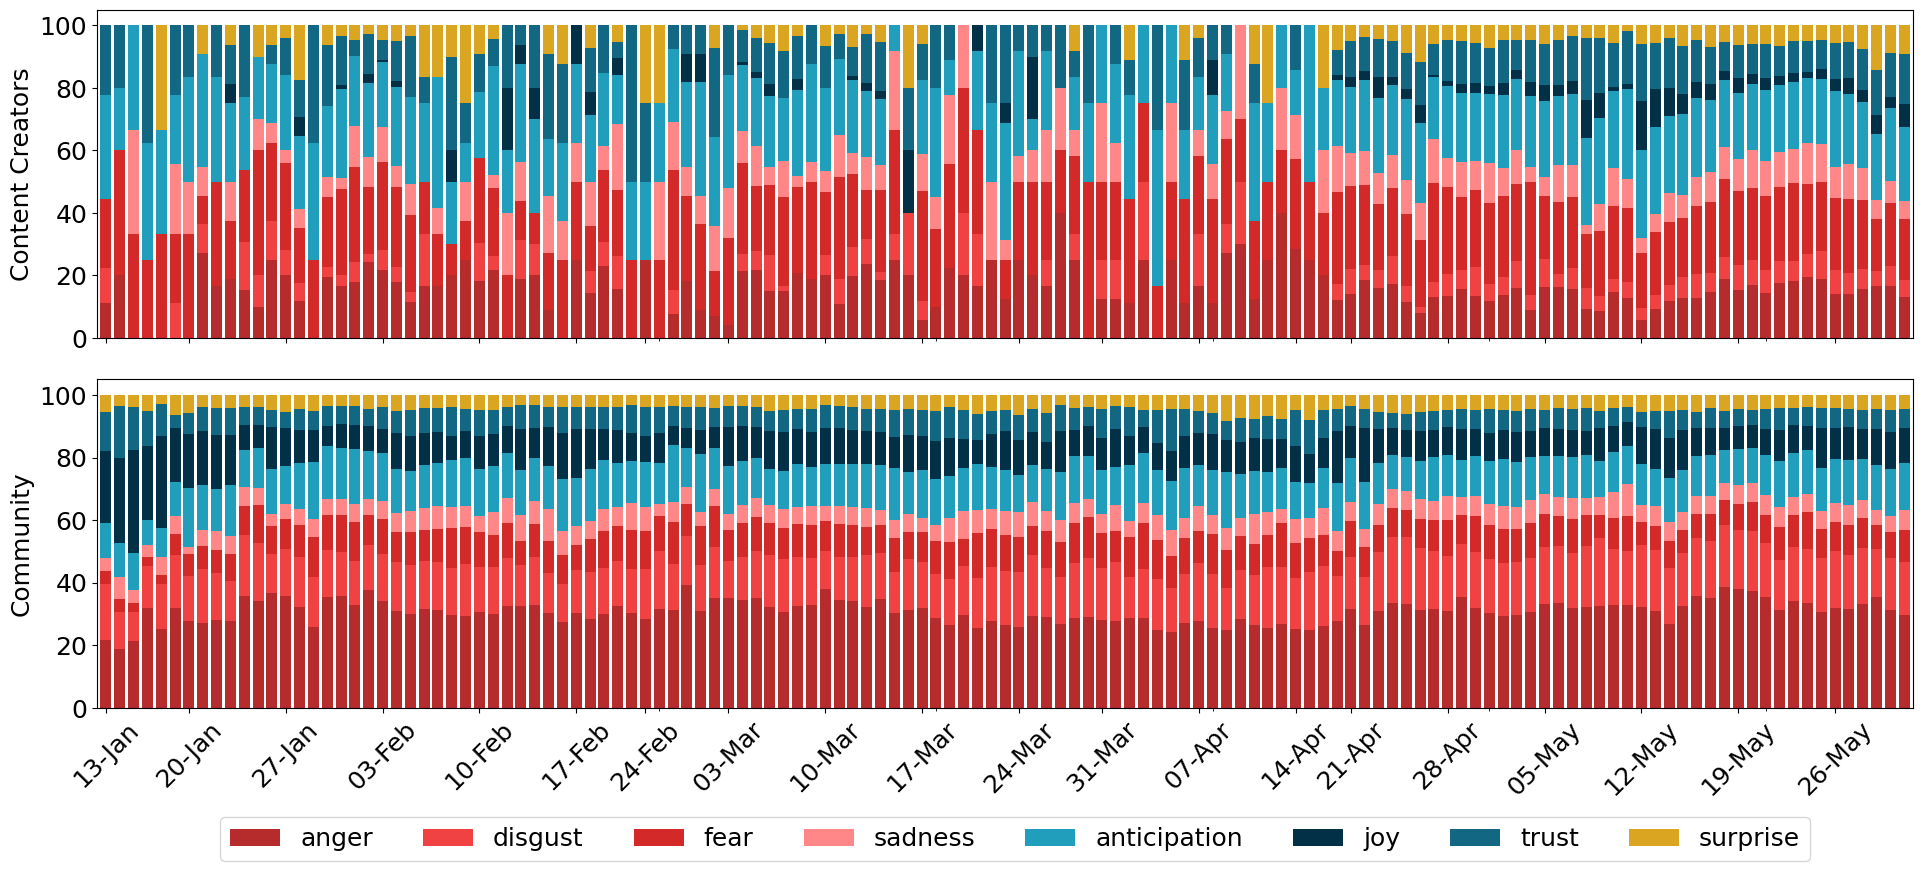

In [10]:
# Plot emotions
plot_stack100(
    df_transcripts_emo_grouped,
    df_comments_emo_grouped,
    datatype='emotion',
    )

/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/index/visualisation.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


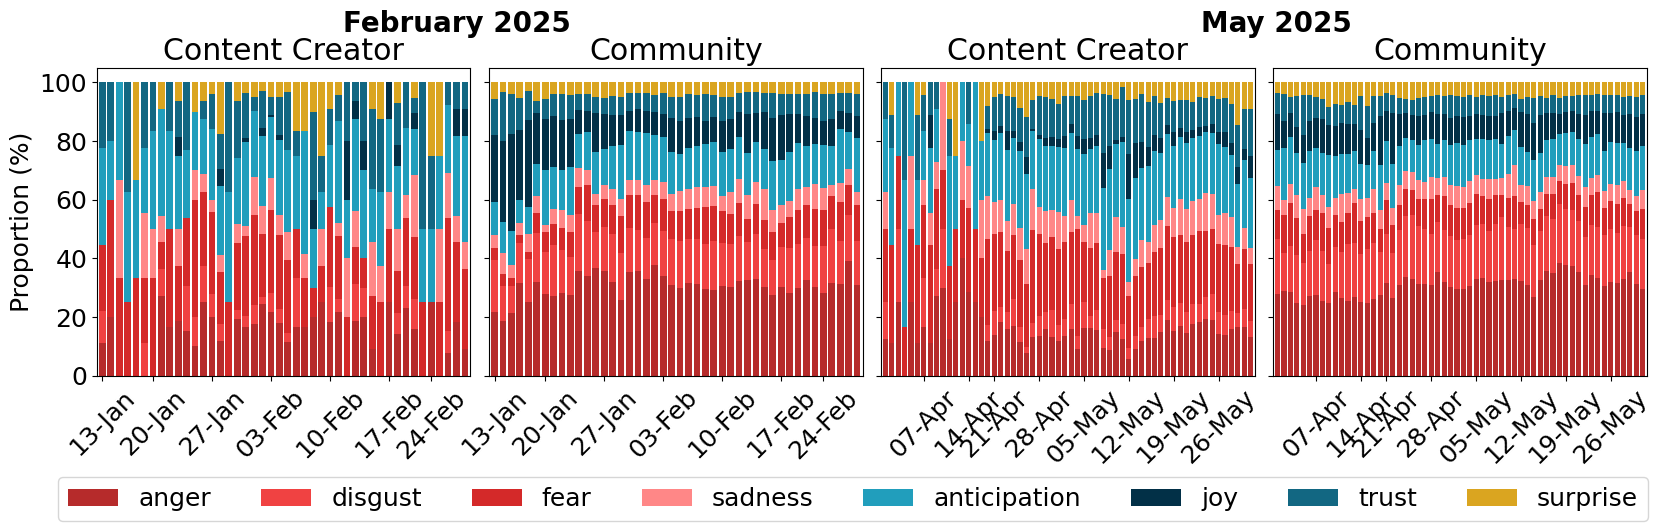

In [11]:
# Plot emotions
date_range1 = {"min": dt.date(2025, 1, 1), "max": dt.date(2025, 2, 28)}
date_range2 = {"min": dt.date(2025, 4, 1), "max": dt.date(2025, 5, 31)}
plot_stack100_split(
    df_transcripts_emo_grouped[(df_transcripts_emo_grouped.date >= date_range1["min"]) & (df_transcripts_emo_grouped.date <= date_range1["max"])],
    df_comments_emo_grouped[(df_comments_emo_grouped.date >= date_range1["min"]) & (df_comments_emo_grouped.date <= date_range1["max"])],
    df_transcripts_emo_grouped[(df_transcripts_emo_grouped.date >= date_range2["min"]) & (df_transcripts_emo_grouped.date <= date_range2["max"])],
    df_comments_emo_grouped[(df_comments_emo_grouped.date >= date_range2["min"]) & (df_comments_emo_grouped.date <= date_range2["max"])],
    datatype='emotion',
    )

## Apply Engagement Weighting (Creator Only)

In [12]:
# Apply engagement weighting to transcripts (creators only) at ROW LEVEL before grouping
# Per index.tex Equation 4: a_v = log(1 + viewCount + likeCount + commentCount)
print("Applying engagement weights to creator data...")
df_transcripts_emo_weighted = apply_engagement_weights(df_transcripts_emo)
print(f"✓ Weighted columns created: {[col for col in df_transcripts_emo_weighted.columns if 'weighted' in col][:5]}...")
print(f"  Total shape: {df_transcripts_emo_weighted.shape}")

Applying engagement weights to creator data...
✓ Weighted columns created: ['anticipation_weighted', 'joy_weighted', 'trust_weighted', 'anger_weighted', 'disgust_weighted']...
  Total shape: (21363, 31)


## Group Data by Date

In [13]:
# Group transcripts - both weighted and non-weighted versions
print("Grouping transcript data by date...")

# Non-weighted version
emotion_cols = POS_EMO + NEG_EMO + [SURPRISE]
df_transcripts_emo_grouped = df_transcripts_emo.groupby('date')[emotion_cols].sum().reset_index()

# Weighted version
weighted_cols = [f"{e}_weighted" for e in emotion_cols]
df_transcripts_emo_weighted_grouped = df_transcripts_emo_weighted.groupby('date')[weighted_cols].sum().reset_index()

# Merge them together
df_transcripts_emo_grouped = pd.merge(
    df_transcripts_emo_grouped,
    df_transcripts_emo_weighted_grouped,
    on='date',
    how='outer'
).fillna(0)

# Group comments (no engagement weighting for community)
df_comments_emo_grouped = df_comments_emo.groupby('date')[emotion_cols].sum().reset_index()

print(f"✓ Transcripts grouped shape: {df_transcripts_emo_grouped.shape}")
print(f"✓ Comments grouped shape: {df_comments_emo_grouped.shape}")

Grouping transcript data by date...
✓ Transcripts grouped shape: (138, 17)
✓ Comments grouped shape: (145, 9)


## Emotion Polarity Index

In [14]:
print("="*70)
print("CALCULATING ALL EMOTION INDICES (EI)")
print("="*70)

# 1. Non-weighted, non-topic EI
print("\n1. Non-weighted, non-topic EI...")
df_transcripts_ei = ei(df_transcripts_emo_grouped, 'creator', weighted=False)
df_comments_ei = ei(df_comments_emo_grouped, 'community', weighted=False)

# 2. Engagement-weighted, non-topic EI
print("2. Engagement-weighted, non-topic EI...")
df_transcripts_ei_weighted = ei(df_transcripts_emo_grouped, 'creator', weighted=True)

# Merge weighted EI into main dataframe
df_transcripts_ei = pd.merge(df_transcripts_ei, 
                              df_transcripts_ei_weighted[['date', 'ei_creator_engweighted']], 
                              on='date', how='outer')

# 3. Topic-level EI (non-weighted)
print("3. Topic-level EI (non-weighted)...")
topic_list_transcripts = [i for i in df_transcripts_emo['topic_level_0'].unique().tolist() if i]
topic_list_comments = [i for i in df_comments_emo['topic_level_0'].unique().tolist() if i]
topic_list = list(set(topic_list_transcripts) | set(topic_list_comments))

df_transcripts_ei_topic = ei_topic(
    df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}), 
    'creator', topic_list, weighted=False
)
df_comments_ei_topic = ei_topic(
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}), 
    'community', topic_list, weighted=False
)

# 4. Topic-level EI (engagement-weighted for creators)
print("4. Topic-level EI (engagement-weighted for creators)...")
df_transcripts_ei_topic_weighted = ei_topic(
    df_transcripts_emo_weighted.rename(columns={"topic_level_0": "topics_corrected"}), 
    'creator', topic_list, weighted=True
)

# 5. Volume-weighted aggregate EI across topics (non-engagement-weighted)
print("5. Volume-weighted aggregate EI across topics...")
df_ei_topicagg = ei_topic_aggregated(
    df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=False
)

# 6. Volume-weighted aggregate EI across topics (engagement-weighted for creators)
print("6. Volume-weighted aggregate EI (engagement-weighted)...")
df_ei_topicagg_weighted = ei_topic_aggregated(
    df_transcripts_emo_weighted.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=True
)

print("\n✓ All EI variants calculated")

CALCULATING ALL EMOTION INDICES (EI)

1. Non-weighted, non-topic EI...
2. Engagement-weighted, non-topic EI...
3. Topic-level EI (non-weighted)...
4. Topic-level EI (engagement-weighted for creators)...
5. Volume-weighted aggregate EI across topics...
6. Volume-weighted aggregate EI (engagement-weighted)...

✓ All EI variants calculated


In [15]:
print("\n" + "="*70)
print("CALCULATING ALL EMOTION POLARITY INDICES (EPI)")
print("="*70)

# 1. Non-weighted, non-topic EPI
print("\n1. Non-weighted, non-topic EPI...")
df_epi = epi(df_transcripts_ei, df_comments_ei, weighted=False)

# 2. Engagement-weighted, non-topic EPI
print("2. Engagement-weighted, non-topic EPI...")
df_epi_weighted = epi(df_transcripts_ei, df_comments_ei, weighted=True)
df_epi = pd.merge(df_epi, df_epi_weighted, on='date', how='outer')

# 3. Signed EPI (non-weighted)
print("3. Signed EPI (non-weighted)...")
df_epi_signed_nw = epi_signed(df_transcripts_ei, df_comments_ei, weighted=False)
df_epi = pd.merge(df_epi, df_epi_signed_nw[['date', 'epi_signed']], on='date', how='outer')

# 4. Signed EPI (engagement-weighted)
print("4. Signed EPI (engagement-weighted)...")
df_epi_signed_w = epi_signed(df_transcripts_ei, df_comments_ei, weighted=True)
df_epi = pd.merge(df_epi, df_epi_signed_w[['date', 'epi_signed_engweighted']], on='date', how='outer')

# 5. Topic-level EPI (non-engagement-weighted) with signed variants per topic
print("5. Topic-level EPI (non-engagement-weighted) with signed variants...")
df_epi_topic = epi_topic(
    df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=False
)

# 6. Topic-level EPI (engagement-weighted for creators) with signed variants per topic
print("6. Topic-level EPI (engagement-weighted) with signed variants...")
df_epi_topic_weighted = epi_topic(
    df_transcripts_emo_weighted.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=True
)

# 7. Volume-weighted aggregate EPI (non-engagement-weighted) with signed variant
print("7. Volume-weighted aggregate EPI...")
df_epi_topicagg = epi_topic_aggregated(
    df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=False
)

# 8. Volume-weighted aggregate EPI (engagement-weighted for creators) with signed variant
print("8. Volume-weighted aggregate EPI (engagement-weighted)...")
df_epi_topicagg_weighted = epi_topic_aggregated(
    df_transcripts_emo_weighted.rename(columns={"topic_level_0": "topics_corrected"}),
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_list, weighted=True
)

# Ensure all dates are datetime before merging
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi_topicagg['date'] = pd.to_datetime(df_epi_topicagg['date'])
df_epi_topicagg_weighted['date'] = pd.to_datetime(df_epi_topicagg_weighted['date'])

# Merge all topic-aggregated versions into main EPI dataframe
df_epi = pd.merge(df_epi, df_epi_topicagg, on='date', how='outer')
df_epi = pd.merge(df_epi, df_epi_topicagg_weighted, on='date', how='outer')

print("\n✓ All EPI variants calculated (including signed variants)")
signed_cols = [c for c in df_epi.columns if 'epi_signed' in c]
print(f"  Signed EPI variants: {len(signed_cols)}")


CALCULATING ALL EMOTION POLARITY INDICES (EPI)

1. Non-weighted, non-topic EPI...
2. Engagement-weighted, non-topic EPI...
3. Signed EPI (non-weighted)...
4. Signed EPI (engagement-weighted)...
5. Topic-level EPI (non-engagement-weighted) with signed variants...
6. Topic-level EPI (engagement-weighted) with signed variants...
7. Volume-weighted aggregate EPI...
8. Volume-weighted aggregate EPI (engagement-weighted)...

✓ All EPI variants calculated (including signed variants)
  Signed EPI variants: 4


In [16]:
print("\n" + "="*70)
print("CALCULATING SURPRISE INDICES (Informational Novelty)")
print("="*70)

# 1. Non-weighted, non-topic Surprise
print("\n1. Non-weighted, non-topic Surprise...")
df_surprise = surprise_index(df_transcripts_emo, df_comments_emo, 
                             topic_col=None, weighted=False)

# 2. Engagement-weighted, non-topic Surprise
print("2. Engagement-weighted, non-topic Surprise...")
df_surprise_weighted = surprise_index(df_transcripts_emo_weighted, df_comments_emo, 
                                      topic_col=None, weighted=True)

# 3. Non-weighted, topic-weighted Surprise
print("3. Volume-weighted Surprise across topics...")
df_surprise_topicweighted = surprise_index(
    df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}), 
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_col='topics_corrected', weighted=False
)

# 4. Engagement-weighted, topic-weighted Surprise
print("4. Engagement & volume-weighted Surprise...")
df_surprise_both = surprise_index(
    df_transcripts_emo_weighted.rename(columns={"topic_level_0": "topics_corrected"}), 
    df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}),
    topic_col='topics_corrected', weighted=True
)

# Merge all surprise versions
df_surprise = pd.merge(df_surprise, df_surprise_weighted, on='date', how='outer')
df_surprise = pd.merge(df_surprise, df_surprise_topicweighted, on='date', how='outer')
df_surprise = pd.merge(df_surprise, df_surprise_both, on='date', how='outer')

print(f"\n✓ All Surprise variants calculated: {[c for c in df_surprise.columns if c != 'date']}")


CALCULATING SURPRISE INDICES (Informational Novelty)

1. Non-weighted, non-topic Surprise...
2. Engagement-weighted, non-topic Surprise...
3. Volume-weighted Surprise across topics...
4. Engagement & volume-weighted Surprise...

✓ All Surprise variants calculated: ['surprise', 'surprise_engweighted', 'surprise_topicweighted', 'surprise_engweighted_topicweighted']


In [17]:
print("\n" + "="*70)
print("CALCULATING SPLIT INDEX (Within-Community Polarization)")
print("="*70)

# Split index (community only, typically non-weighted)
print("\nCalculating Split index...")
df_split = split_index(df_comments_emo, weighted=False)

print(f"\n✓ Split index calculated: {[c for c in df_split.columns if c != 'date']}")


CALCULATING SPLIT INDEX (Within-Community Polarization)

Calculating Split index...

✓ Split index calculated: ['split']


In [18]:
print("\n" + "="*70)
print("MERGING ALL INDICES & SUMMARY")
print("="*70)

# Ensure all date columns are datetime before merging
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_surprise['date'] = pd.to_datetime(df_surprise['date'])
df_split['date'] = pd.to_datetime(df_split['date'])

# Create comprehensive index dataset
df_indices_complete = df_epi.copy()
df_indices_complete = pd.merge(df_indices_complete, df_surprise, on='date', how='outer')
df_indices_complete = pd.merge(df_indices_complete, df_split, on='date', how='outer')

# Sort by date
df_indices_complete = df_indices_complete.sort_values('date').reset_index(drop=True)

# Fill Nans with 0
df_indices_complete.fillna(0, inplace=True)

print(f"\n✓ Complete index dataset created")
print(f"   Shape: {df_indices_complete.shape}")
print(f"   Date range: {df_indices_complete['date'].min().date()} to {df_indices_complete['date'].max().date()}")

# Display available indices by category
print("\n" + "-"*70)
print("AVAILABLE INDICES BY CATEGORY:")
print("-"*70)

ei_cols = [c for c in df_indices_complete.columns if c.startswith('ei_')]
epi_cols = [c for c in df_indices_complete.columns if c.startswith('epi') and 'epi_signed' not in c]
epi_signed_cols = [c for c in df_indices_complete.columns if 'epi_signed' in c]
ccd_cols = [c for c in df_indices_complete.columns if c.startswith('ccd')]
int_cols = [c for c in df_indices_complete.columns if c.startswith('intensity')]
surp_cols = [c for c in df_indices_complete.columns if c.startswith('surprise')]
split_cols = [c for c in df_indices_complete.columns if c.startswith('split')]

print(f"  EI (Emotion Index): {len(ei_cols)} variants")
print(f"  EPI (Emotion Polarity Index): {len(epi_cols)} variants")
print(f"  EPI Signed: {len(epi_signed_cols)} variants")
print(f"  CCD (Creator-Community Divergence): {len(ccd_cols)} variants")
print(f"  Intensity: {len(int_cols)} variants")
print(f"  Surprise: {len(surp_cols)} variants")
print(f"  Split: {len(split_cols)} variants")

# Summary statistics for main indices
print("\n" + "-"*70)
print("SUMMARY STATISTICS (Main Aggregate Indices):")
print("-"*70)

main_indices = ['epi', 'epi_engweighted', 'epi_topicweighted', 'epi_engweighted_topicweighted',
                'ccd', 'ccd_engweighted', 'intensity', 'intensity_engweighted',
                'surprise', 'surprise_engweighted', 'surprise_topicweighted', 
                'surprise_engweighted_topicweighted', 'split']

available_main = [col for col in main_indices if col in df_indices_complete.columns]
summary_df = df_indices_complete[available_main].describe().T
summary_df['range'] = summary_df['max'] - summary_df['min']
print(summary_df[['mean', 'std', 'min', 'max', 'range']].round(4))


MERGING ALL INDICES & SUMMARY

✓ Complete index dataset created
   Shape: (148, 30)
   Date range: 2025-01-02 to 2025-05-31

----------------------------------------------------------------------
AVAILABLE INDICES BY CATEGORY:
----------------------------------------------------------------------
  EI (Emotion Index): 8 variants
  EPI (Emotion Polarity Index): 4 variants
  EPI Signed: 4 variants
  CCD (Creator-Community Divergence): 4 variants
  Intensity: 4 variants
  Surprise: 4 variants
  Split: 1 variants

----------------------------------------------------------------------
SUMMARY STATISTICS (Main Aggregate Indices):
----------------------------------------------------------------------
                                      mean     std     min     max   range
epi                                 0.0431  0.0496  0.0000  0.2500  0.2500
epi_engweighted                     0.0419  0.0486  0.0000  0.2500  0.2500
epi_topicweighted                   0.0281  0.0234  0.0000  0.1215  0.1

## Visualise Indices Over Time

The `plot_indices` function allows you to visualize different types of indices with all their variants:

**Available index types:**
- `'ei'` - Emotion Index (Creator, Community, Engagement-weighted)
- `'epi'` - Emotion Polarity Index (4 variants)
- `'epi_signed'` - Signed EPI (2 variants)
- `'ccd'` - Creator-Community Divergence (2 variants)
- `'intensity'` - Emotional Intensity (2 variants)
- `'surprise'` - Surprise Index (4 variants)
- `'split'` - Split Index (Community polarization)

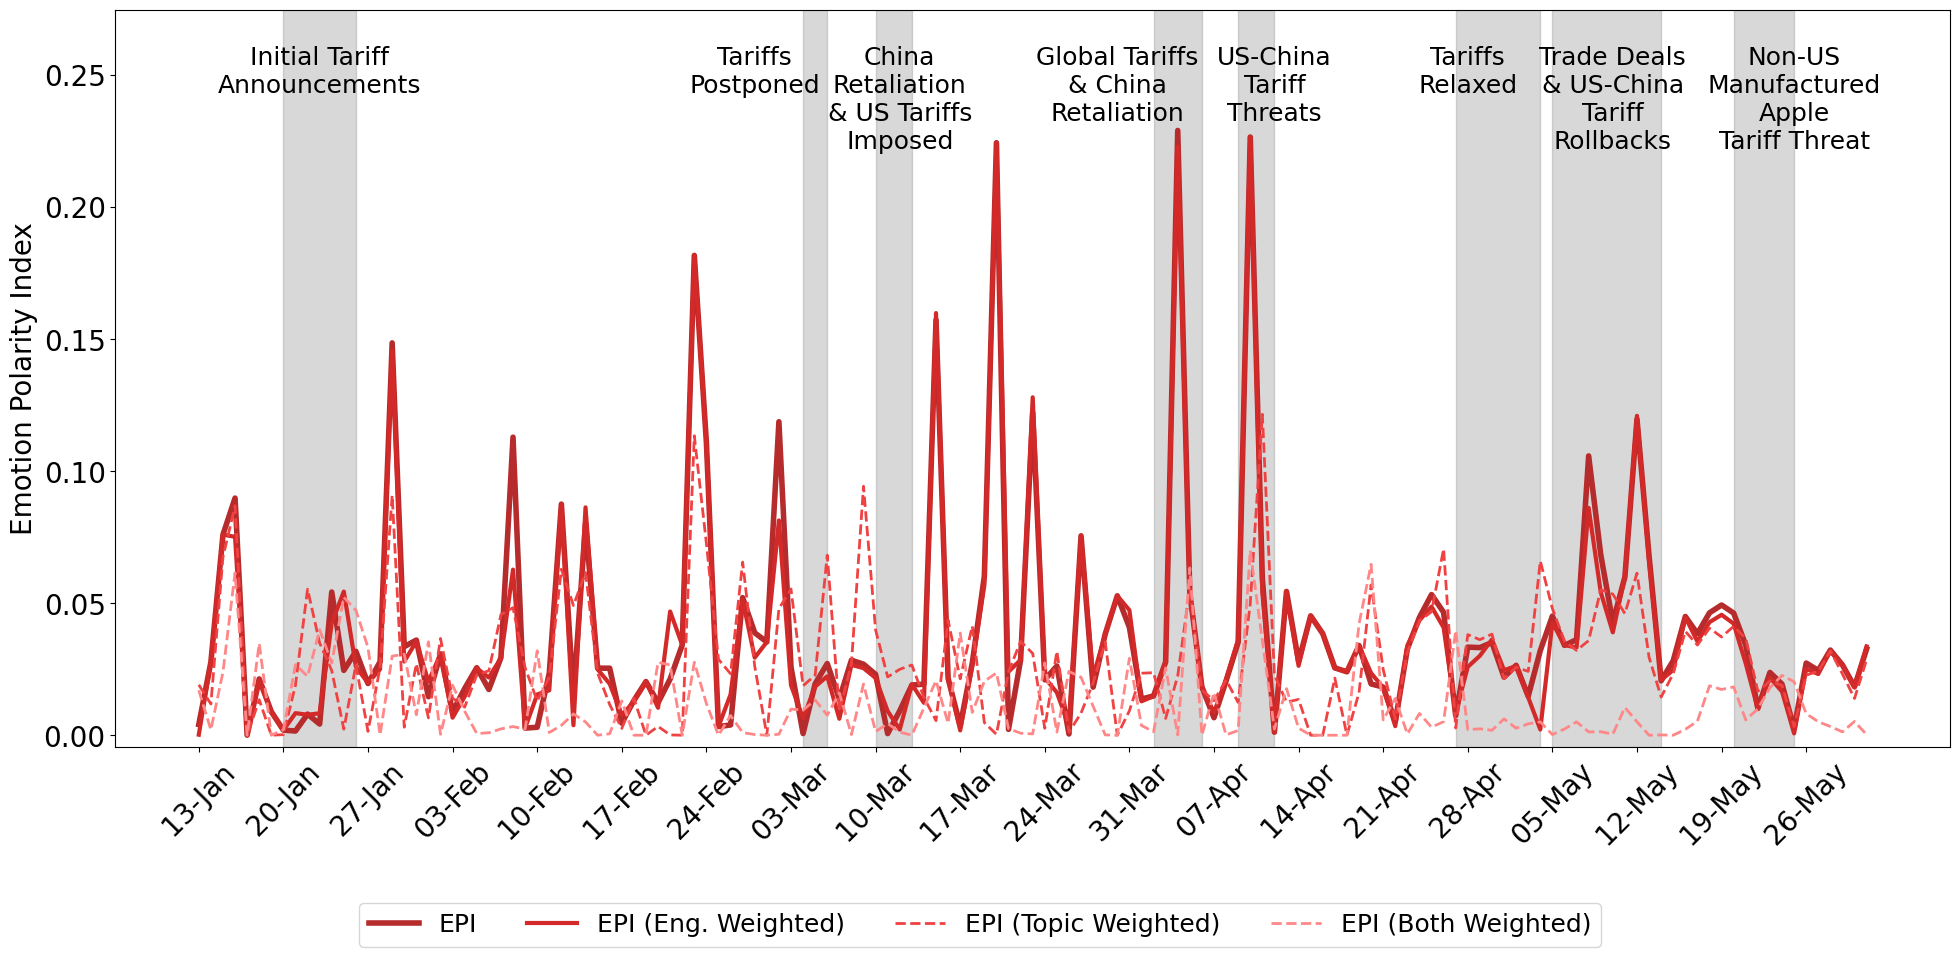

In [19]:
# Example 1: Plot all EPI variants
plot_indices(df_indices_complete, index_type='epi')

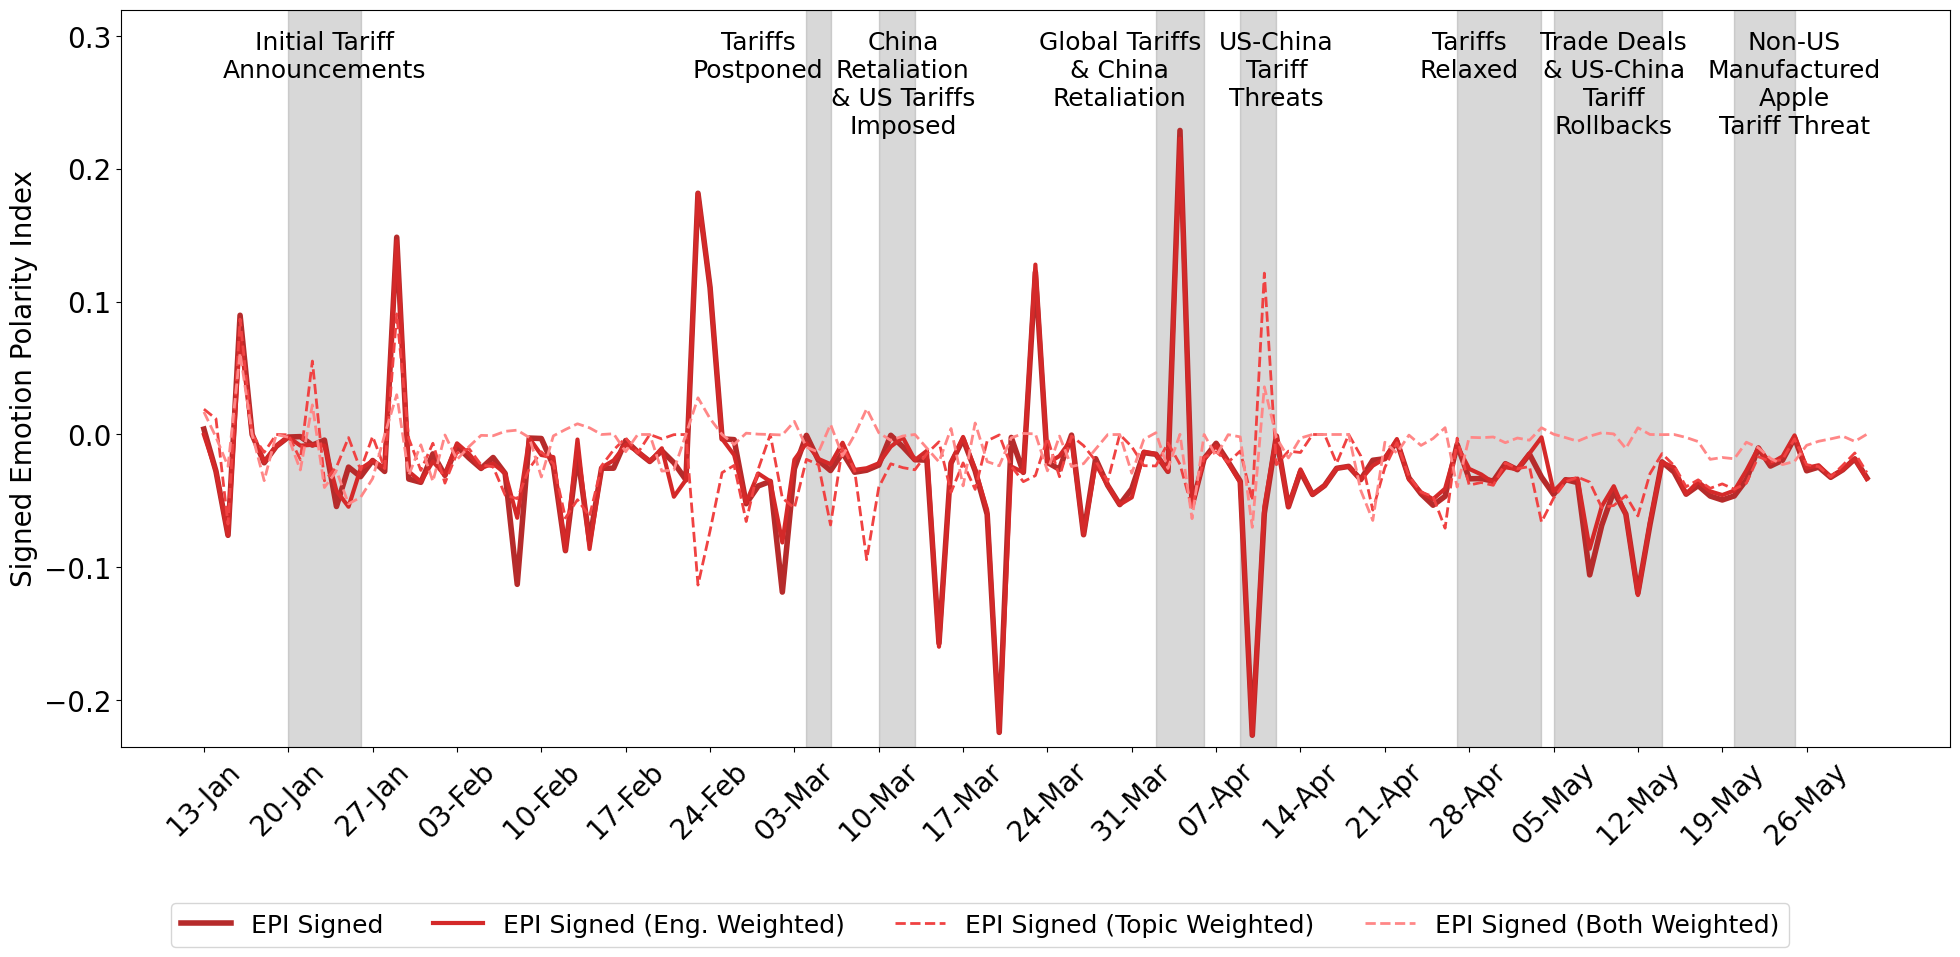

In [20]:
# Example 2: Plot all EPI Signed variants
plot_indices(df_indices_complete, index_type='epi_signed')

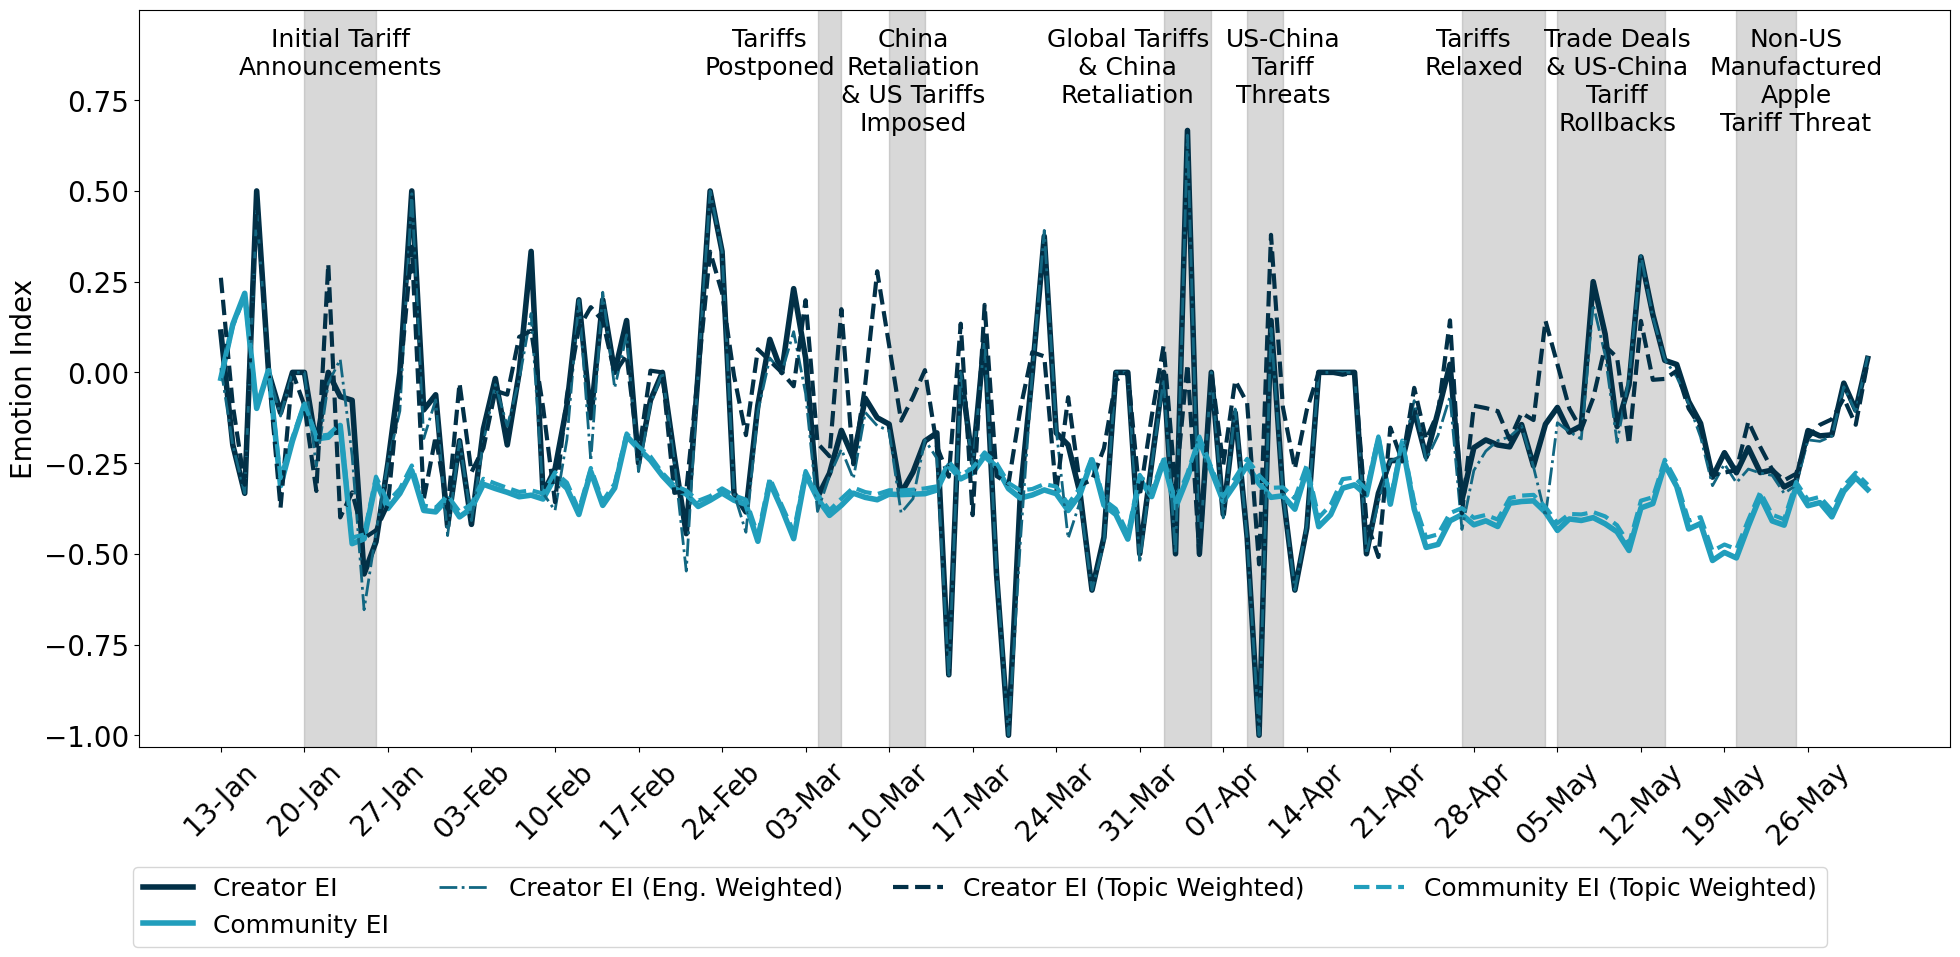

In [21]:
# Example 2: Plot Emotion Index with creator and community
plot_indices(df_indices_complete, index_type='ei')

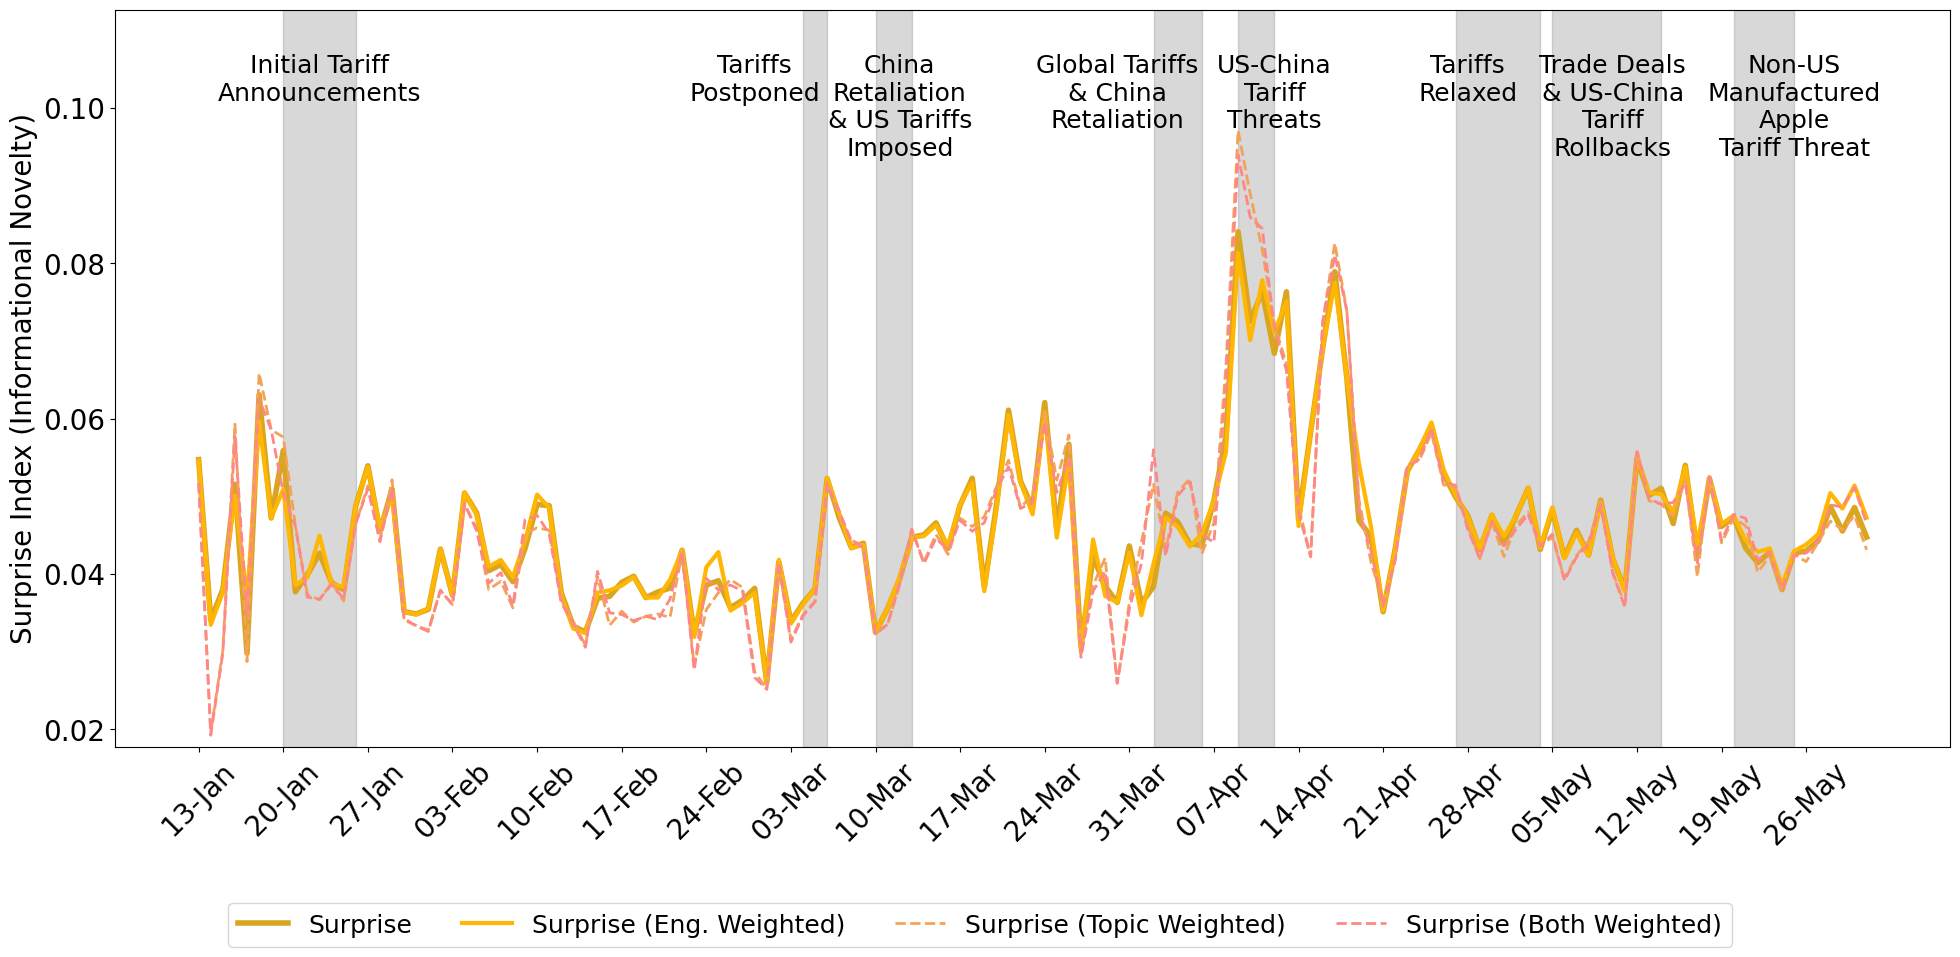

In [22]:
# Example 3: Plot Surprise Index variants
plot_indices(df_indices_complete, index_type='surprise')

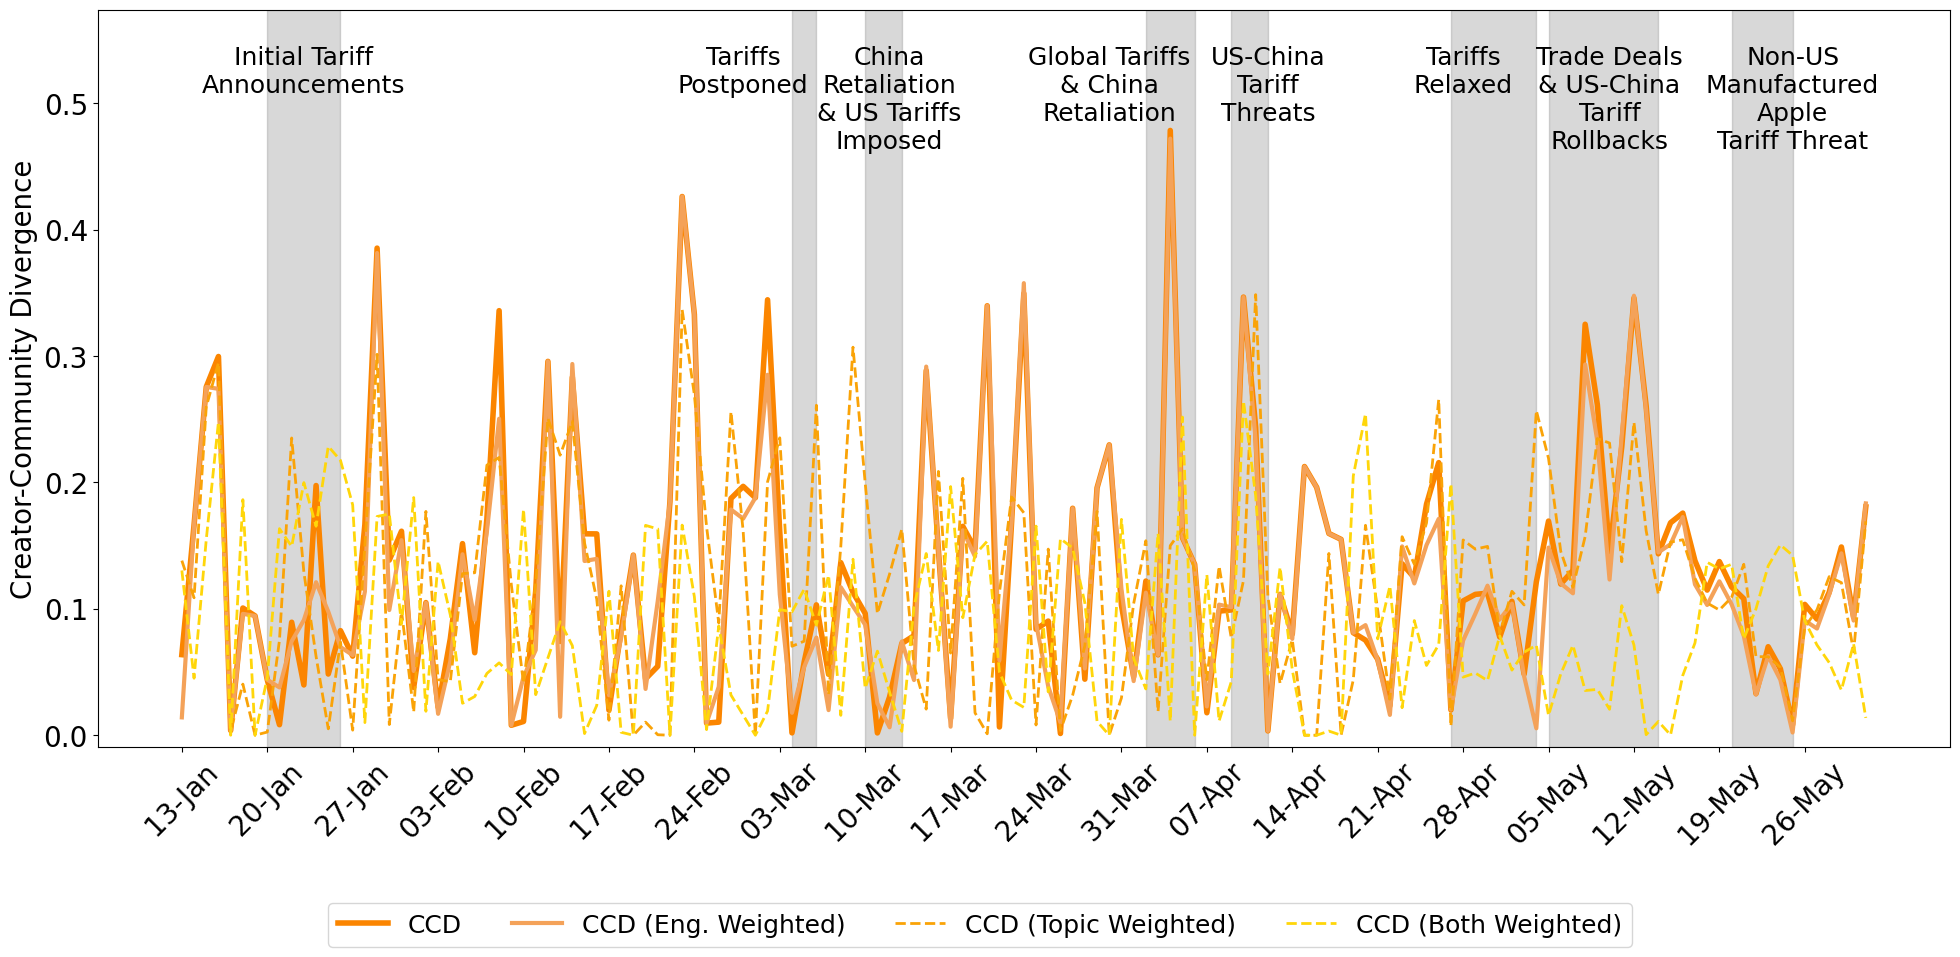

In [23]:
# Example 4: Plot CCD (Creator-Community Divergence)
plot_indices(df_indices_complete, index_type='ccd')

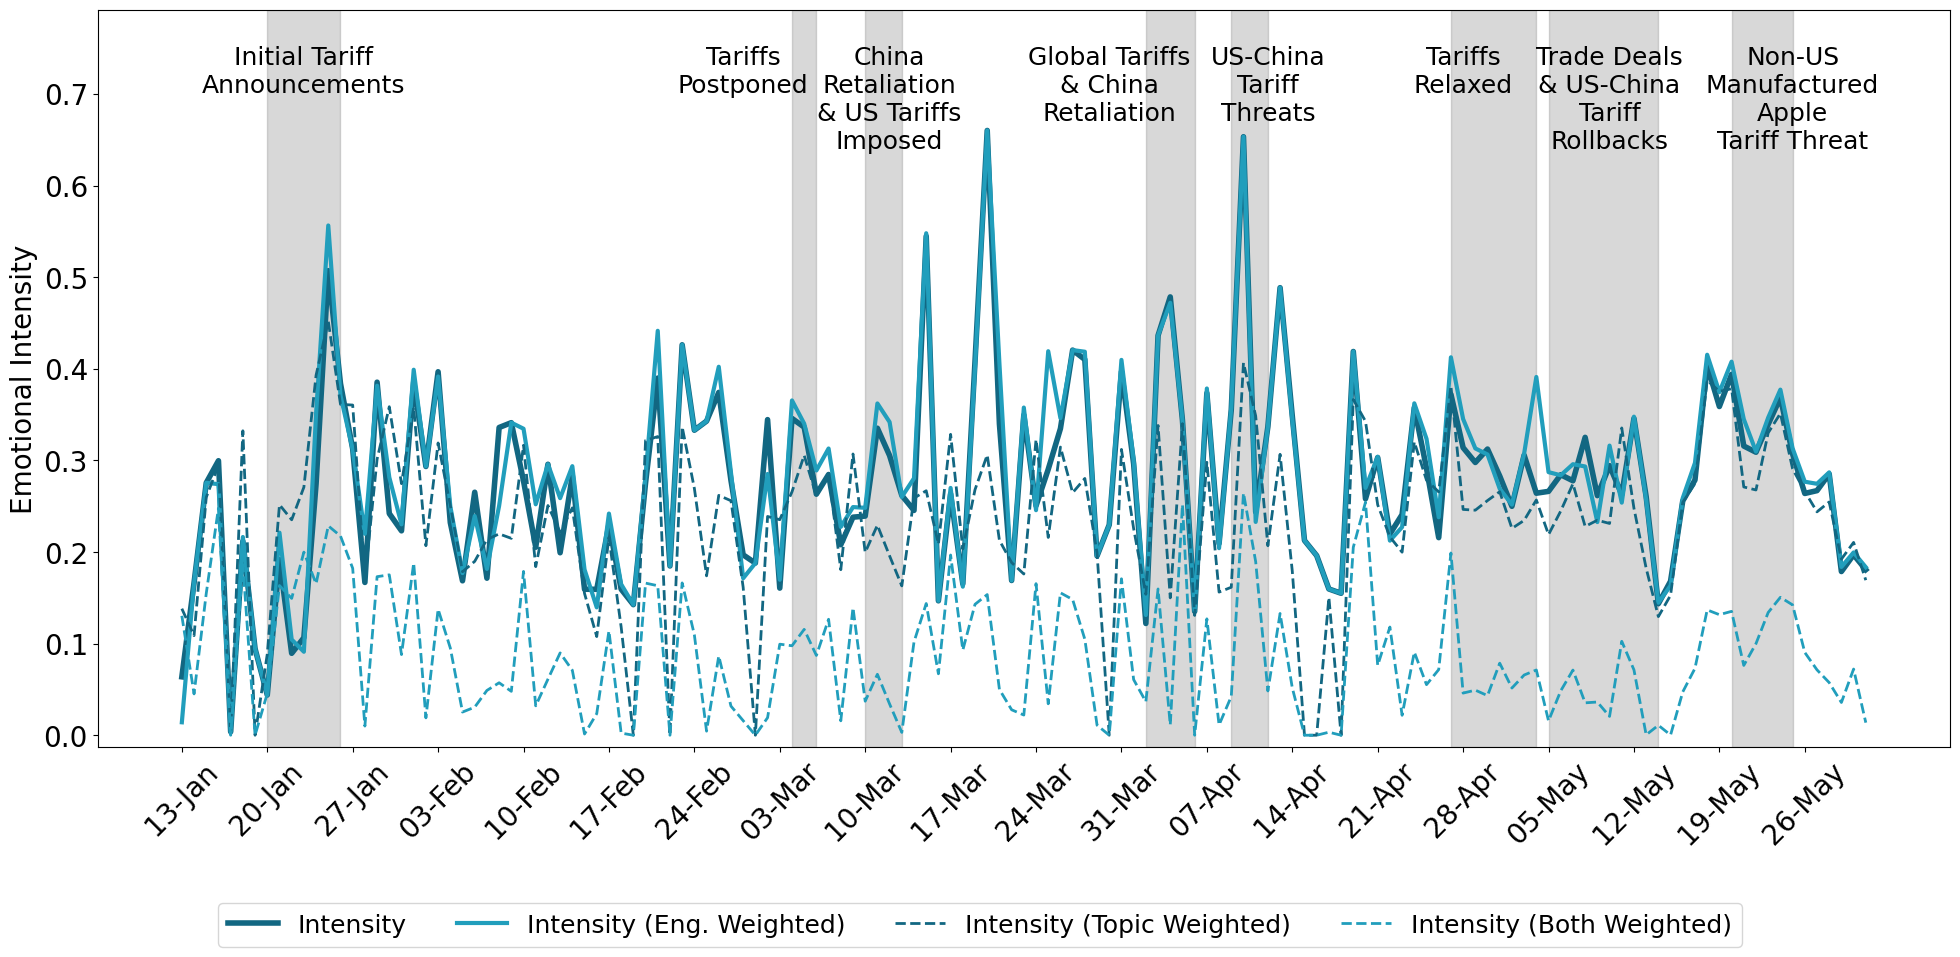

In [24]:
# Example 5: Plot Intensity
plot_indices(df_indices_complete, index_type='intensity')

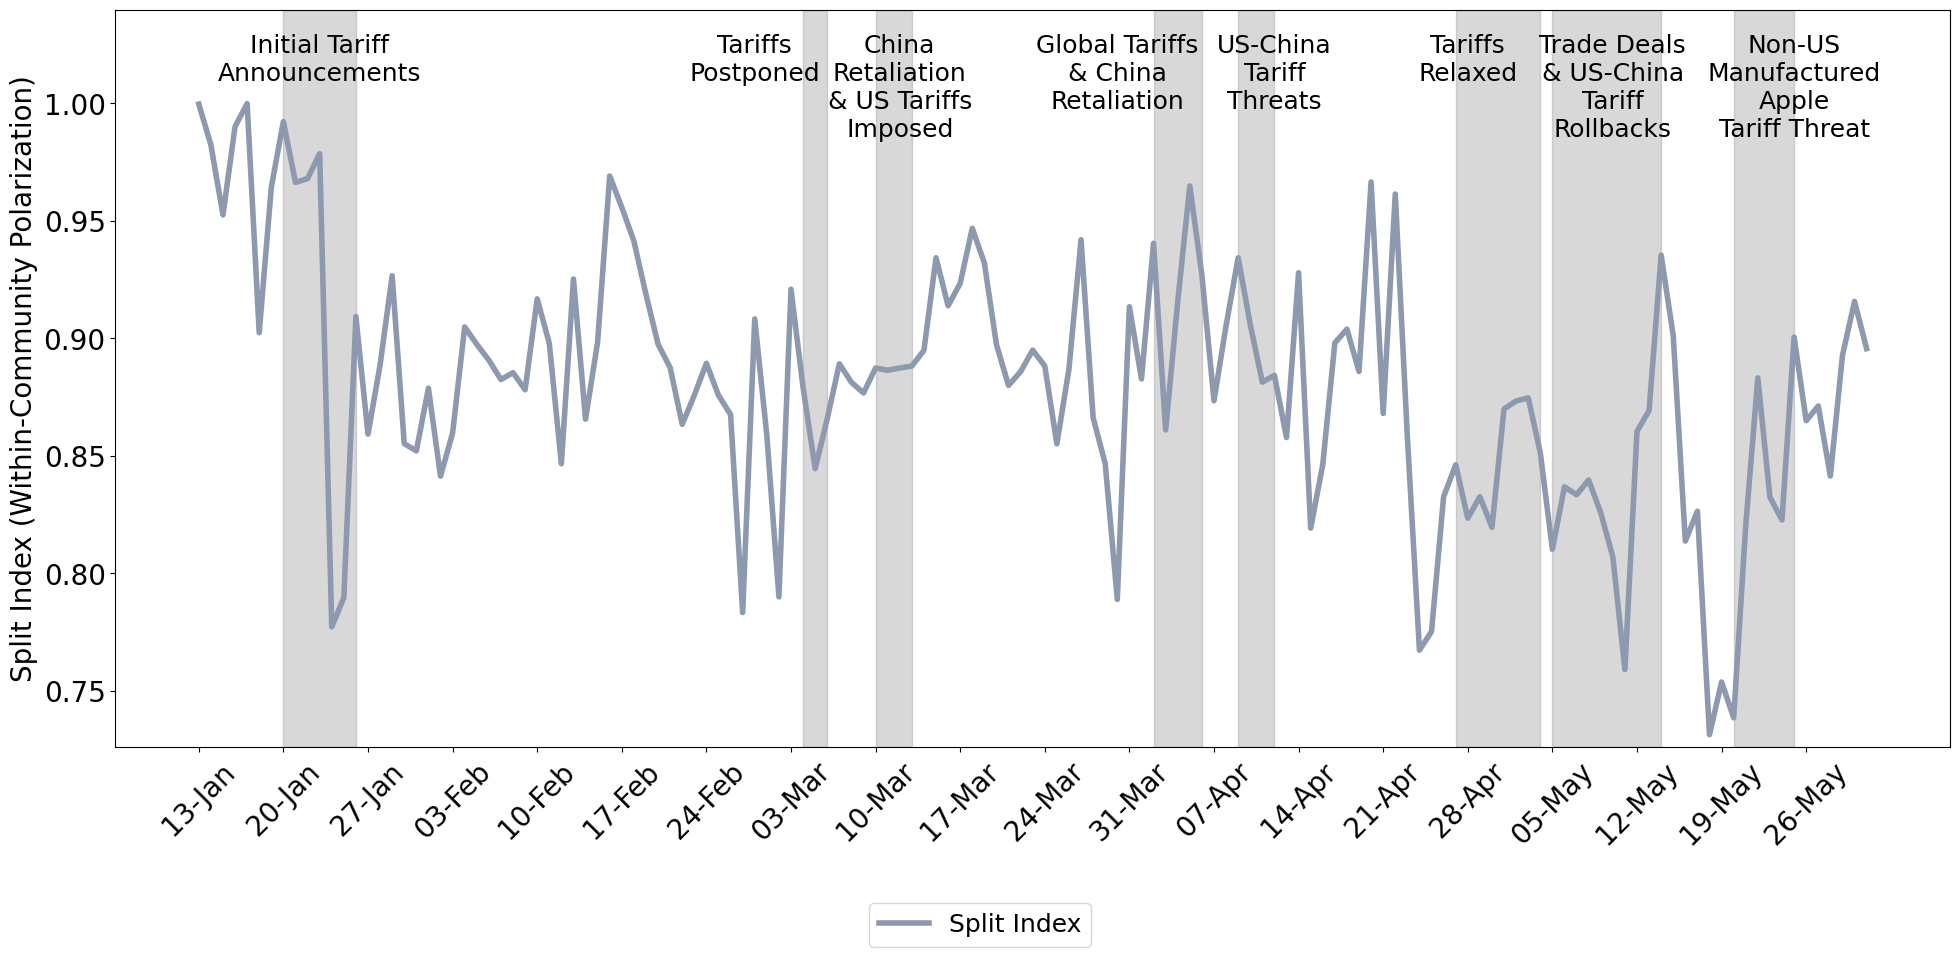

In [25]:
# Example 6: Plot Split
plot_indices(df_indices_complete, index_type='split')

In [26]:
df_indices_complete_copy = deepcopy(df_indices_complete)
df_key_moments = df_indices_complete_copy[
        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-01-20")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-01-26")) |

        # (df_indices_complete_copy['date'] >= pd.to_datetime("2025-02-10")) &
        # (df_indices_complete_copy['date'] <= pd.to_datetime("2025-02-13")) |

        # (df_indices_complete_copy['date'] >= pd.to_datetime("2025-02-22")) &
        # (df_indices_complete_copy['date'] <= pd.to_datetime("2025-02-26")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-03-04")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-03-06")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-03-10")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-03-13")) |

        # (df_indices_complete_copy['date'] >= pd.to_datetime("2025-03-22")) &
        # (df_indices_complete_copy['date'] <= pd.to_datetime("2025-03-26")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-04-02")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-04-06")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-04-09")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-04-12")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-04-27")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-05-04")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-05-05")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-05-14")) |

        (df_indices_complete_copy['date'] >= pd.to_datetime("2025-05-20")) &
        (df_indices_complete_copy['date'] <= pd.to_datetime("2025-05-25"))
]

df_not_key_moments = df_indices_complete_copy[~df_indices_complete_copy['date'].isin(df_key_moments['date'])]

In [27]:
# Summary statistics for main indices
print("\n" + "-"*70)
print("SUMMARY STATISTICS (Key Moments):")
print("-"*70)

main_indices = ['epi', 'epi_engweighted', 'epi_topicweighted', 'epi_engweighted_topicweighted',
                'ccd', 'ccd_engweighted', 'intensity', 'intensity_engweighted',
                'surprise', 'surprise_engweighted', 'surprise_topicweighted', 
                'surprise_engweighted_topicweighted', 'split']

available_main = [col for col in main_indices if col in df_key_moments.columns]
summary_df_key_moments = df_key_moments[available_main].describe().T
summary_df_key_moments['range'] = summary_df_key_moments['max'] - summary_df_key_moments['min']
print(summary_df_key_moments[['mean', 'std', 'min', 'max', 'range']].round(4))


----------------------------------------------------------------------
SUMMARY STATISTICS (Key Moments):
----------------------------------------------------------------------
                                      mean     std     min     max   range
epi                                 0.0390  0.0474  0.0006  0.2290  0.2284
epi_engweighted                     0.0372  0.0463  0.0007  0.2265  0.2258
epi_topicweighted                   0.0323  0.0215  0.0002  0.1215  0.1213
epi_engweighted_topicweighted       0.0136  0.0178  0.0000  0.0699  0.0699
ccd                                 0.1222  0.1030  0.0018  0.4785  0.4767
ccd_engweighted                     0.1149  0.0999  0.0022  0.4721  0.4699
intensity                           0.2967  0.1066  0.0439  0.6533  0.6095
intensity_engweighted               0.3075  0.1108  0.0439  0.6533  0.6094
surprise                            0.0467  0.0104  0.0325  0.0841  0.0516
surprise_engweighted                0.0468  0.0101  0.0326  0.0813  0.048

In [28]:
# Summary statistics for main indices
print("\n" + "-"*70)
print("SUMMARY STATISTICS (Non Key Moments):")
print("-"*70)

main_indices = ['epi', 'epi_engweighted', 'epi_topicweighted', 'epi_engweighted_topicweighted',
                'ccd', 'ccd_engweighted', 'intensity', 'intensity_engweighted',
                'surprise', 'surprise_engweighted', 'surprise_topicweighted', 
                'surprise_engweighted_topicweighted', 'split']

available_main = [col for col in main_indices if col in df_not_key_moments.columns]
summary_df_not_key_moments = df_not_key_moments[available_main].describe().T
summary_df_not_key_moments['range'] = summary_df_not_key_moments['max'] - summary_df_not_key_moments['min']
print(summary_df_not_key_moments[['mean', 'std', 'min', 'max', 'range']].round(4))


----------------------------------------------------------------------
SUMMARY STATISTICS (Non Key Moments):
----------------------------------------------------------------------
                                      mean     std     min     max   range
epi                                 0.0451  0.0507  0.0000  0.2500  0.2500
epi_engweighted                     0.0442  0.0498  0.0000  0.2500  0.2500
epi_topicweighted                   0.0261  0.0240  0.0000  0.1134  0.1134
epi_engweighted_topicweighted       0.0105  0.0135  0.0000  0.0647  0.0647
ccd                                 0.1526  0.1103  0.0014  0.5000  0.4986
ccd_engweighted                     0.1468  0.1087  0.0037  0.5000  0.4963
intensity                           0.2717  0.1083  0.0037  0.6602  0.6565
intensity_engweighted               0.2786  0.1104  0.0037  0.6602  0.6565
surprise                            0.0443  0.0132  0.0000  0.0909  0.0909
surprise_engweighted                0.0447  0.0140  0.0000  0.1133  0

In [29]:
print("------\nTranscripts\n------")
for i in topic_cols:
    print(f"{i}: {len(df_transcripts_emo[i].unique())} unique values")
print("\n------\nComments & Replies\n------")
for i in topic_cols:
    print(f"{i}: {len(df_comments_emo[i].unique())} unique values")
print("\n------\nALL\n------")
for i in topic_cols:
    print(f"{i}: {len(set(list(df_comments_emo[i].unique())+list(df_transcripts_emo[i].unique())))} unique values")

------
Transcripts
------
BERTopic: 2655 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 71 unique values
topic_level_3: 186 unique values
topic_level_4: 656 unique values

------
Comments & Replies
------
BERTopic: 6126 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 77 unique values
topic_level_3: 208 unique values
topic_level_4: 898 unique values

------
ALL
------
BERTopic: 6126 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 77 unique values
topic_level_3: 208 unique values
topic_level_4: 898 unique values


In [30]:
topic_list_transcripts = [i for i in df_transcripts_emo['topic_level_0'].unique().tolist() if i]
topic_list_comments = [i for i in df_comments_emo['topic_level_0'].unique().tolist() if i]

In [31]:
# combine topic lists
topic_list = list(set(topic_list_transcripts) | set(topic_list_comments))

In [32]:
# Plot topics
df_transcripts_topics = deepcopy(df_transcripts_emo)
df_comments_topics = deepcopy(df_comments_emo)

sorted_topic_list = sorted(topic_list)
for i in sorted_topic_list:
    if i:
        df_transcripts_topics[f"{i}"] = np.where(df_transcripts_topics[f"topic_level_0"]==i, 1, 0)
        df_comments_topics[f"{i}"] = np.where(df_comments_topics[f"topic_level_0"]==i, 1, 0)

df_transcripts_grouped_topics = df_transcripts_topics.groupby(['date'])[sorted_topic_list].sum().reset_index()
df_comments_grouped_topics = df_comments_topics.groupby(['date'])[sorted_topic_list].sum().reset_index()

In [33]:
# Get percentage of topics
df_transcripts_grouped_topics['total'] = df_transcripts_grouped_topics[topic_list].sum(axis=1)
df_comments_grouped_topics['total'] = df_comments_grouped_topics[topic_list].sum(axis=1)

for i in topic_list:
    df_transcripts_grouped_topics[f"{i}_percent"] = df_transcripts_grouped_topics[f"{i}"] / df_transcripts_grouped_topics['total']
    df_comments_grouped_topics[f"{i}_percent"] = df_comments_grouped_topics[f"{i}"] / df_comments_grouped_topics['total']

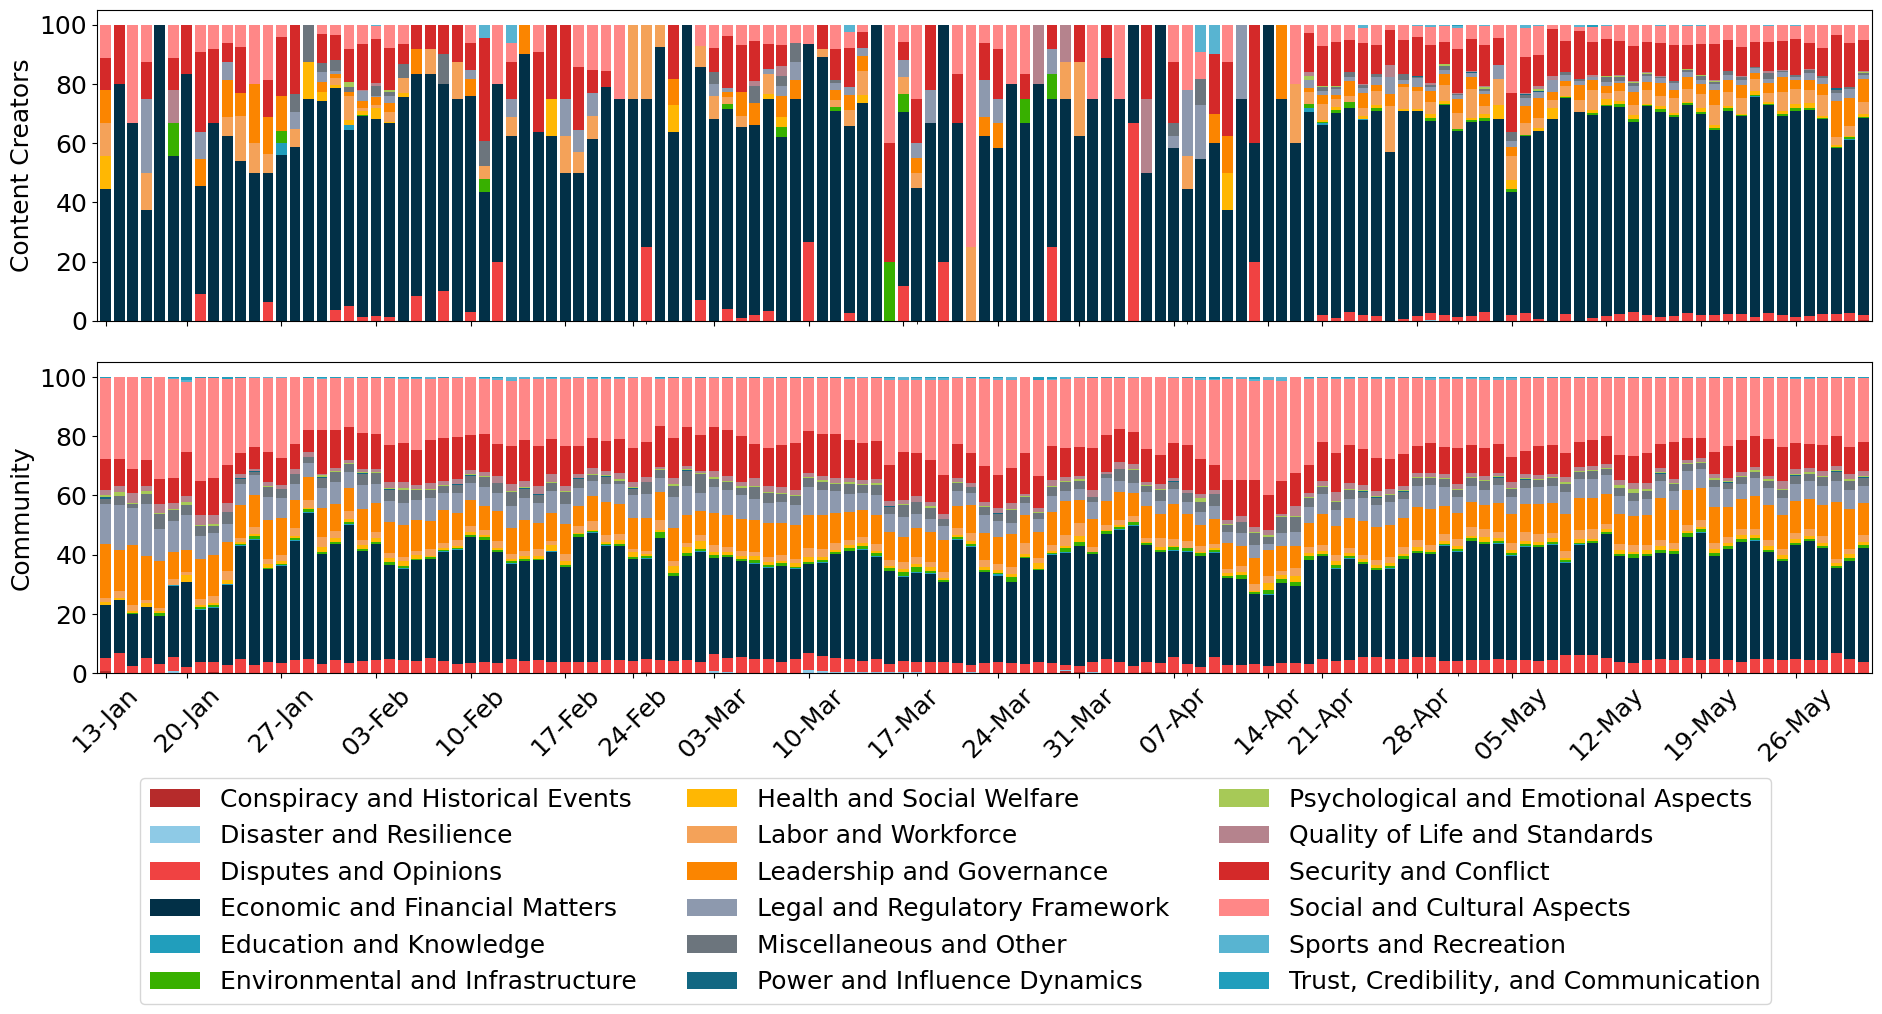

In [34]:
# Plot emotions
plot_stack100(
    df_transcripts_grouped_topics,
    df_comments_grouped_topics,
    datatype='topic',
    legend_cols=3,
    legend_add_gap=-0.3,
    )

/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/index/visualisation.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


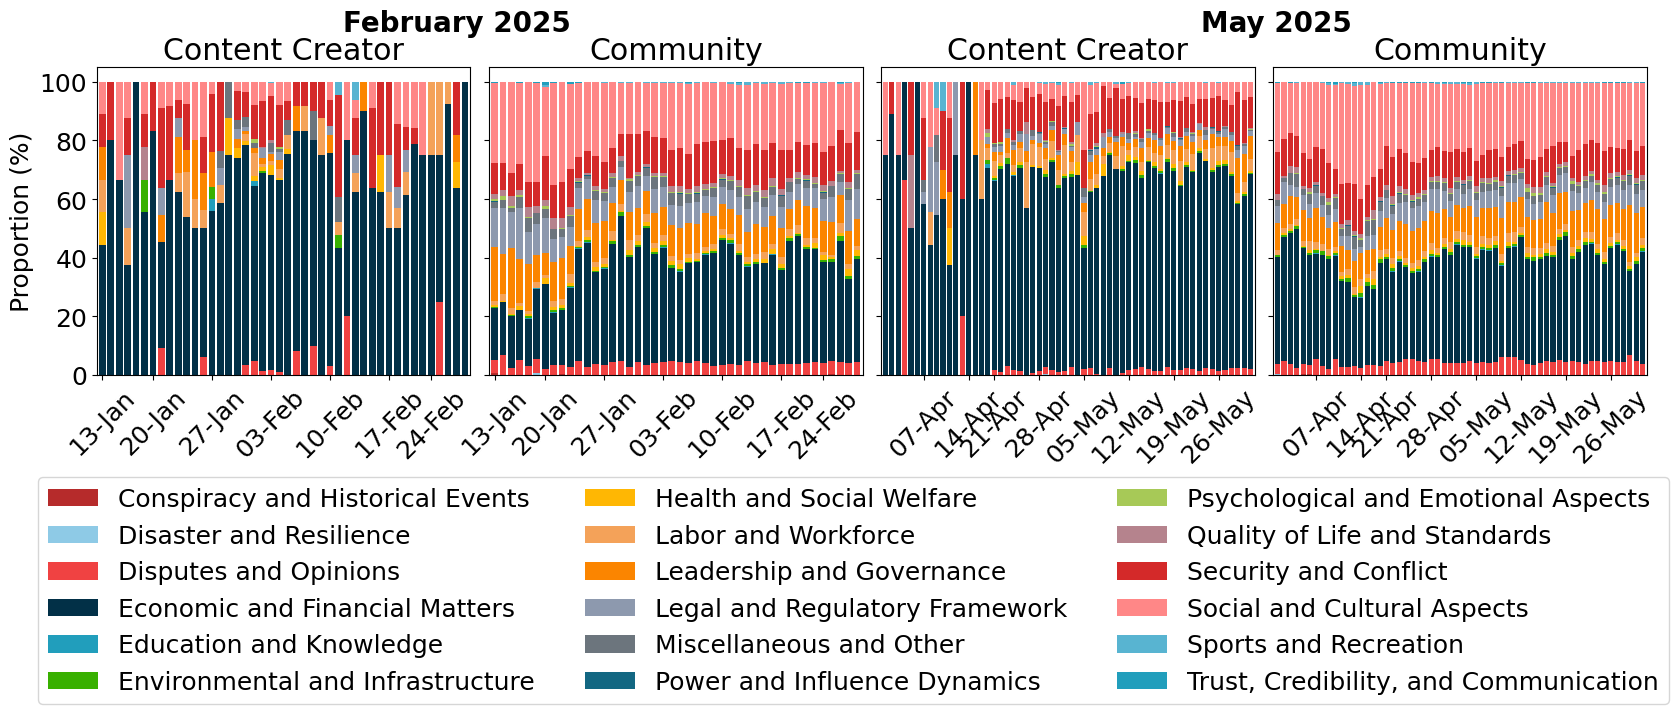

In [35]:
plot_stack100_split(
    df_transcripts_grouped_topics[(df_transcripts_grouped_topics.date >= date_range1["min"]) & (df_transcripts_grouped_topics.date <= date_range1["max"])],
    df_comments_grouped_topics[(df_comments_grouped_topics.date >= date_range1["min"]) & (df_comments_grouped_topics.date <= date_range1["max"])],
    df_transcripts_grouped_topics[(df_transcripts_grouped_topics.date >= date_range2["min"]) & (df_transcripts_grouped_topics.date <= date_range2["max"])],
    df_comments_grouped_topics[(df_comments_grouped_topics.date >= date_range2["min"]) & (df_comments_grouped_topics.date <= date_range2["max"])],
    datatype='topic',
    legend_cols=3,
    legend_add_gap=-0.3,
    )

In [36]:
topic_percentages = {
    "Transcripts": {},
    "Comments": {},
    "Overall" : {},
}

for i in sorted_topic_list:
    topic_percentages["Transcripts"][i] = np.mean(df_transcripts_grouped_topics[f"{i}_percent"])*100
    topic_percentages["Comments"][i] = np.mean(df_comments_grouped_topics[f"{i}_percent"])*100
    topic_percentages["Overall"][i] = (topic_percentages["Transcripts"][i] + topic_percentages["Comments"][i])/2

pd.DataFrame(topic_percentages).map(lambda x: f"{x:.2f}%" if isinstance(x, (int, float, np.floating)) else x)

,Transcripts,Comments,Overall
Conspiracy and Historical Events,0.00%,0.09%,0.04%
Disaster and Resilience,0.00%,0.06%,0.03%
Disputes and Opinions,2.64%,4.05%,3.35%
Economic and Financial Matters,66.09%,33.55%,49.82%
Education and Knowledge,0.06%,0.11%,0.09%
Environmental and Infrastructure,0.68%,0.75%,0.72%
Health and Social Welfare,1.08%,1.10%,1.09%
Labor and Workforce,4.08%,2.03%,3.06%
Leadership and Governance,3.02%,10.52%,6.77%
Legal and Regulatory Framework,2.63%,6.58%,4.60%


## Export EPI Data to JSON

In [50]:
pd.set_option('display.max_rows', None)

In [55]:
def summarise(df, exclude_cols=['date']):
    """
    Generate summary statistics including count and percentage of zeros.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe to summarize
    exclude_cols : list
        List of column names to exclude from summary (default: ['date'])
    
    Returns:
    --------
    pd.DataFrame
        Summary statistics with mean, std, min, max, range, count_zeros, pct_zeros
    """
    # Get numeric columns excluding specified columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Generate base summary
    summary_df = df[numeric_cols].describe().T
    
    # Add custom metrics
    summary_df['range'] = summary_df['max'] - summary_df['min']
    summary_df['count_zeros'] = df[numeric_cols].apply(lambda x: (x == 0).sum())
    summary_df['null'] = (summary_df['count_zeros'] / summary_df['count']) * 100
    
    return summary_df[['mean', 'std', 'min', 'max', 'range', 'null']]

In [57]:
# Prepare for export
df_export = df_indices_complete.copy()
df_export['date'] = df_export['date'].dt.strftime('%Y-%m-%d')
df_export.drop(columns=['ei_community_y', 'ei_community_engweighted_topicweighted'], inplace=True)
df_export.rename(columns={'ei_community_x': 'ei_community'}, inplace=True)

cols = df_export.columns.tolist()
cols_sorted = ['date'] + sorted([col for col in cols if col != 'date'])
df_export = df_export[cols_sorted]

summarise(df_export.copy())

,mean,std,min,max,range,null
ccd,0.142941,0.108585,0.001404,0.500000,0.498596,0.000000
ccd_engweighted,0.136688,0.106680,0.002163,0.500000,0.497837,0.000000
ccd_engweighted_topicweighted,0.082691,0.068524,0.000000,0.264471,0.264471,10.810811
ccd_topicweighted,0.116920,0.086060,0.000000,0.348601,0.348601,8.783784
ei_community,-0.322693,0.117570,-0.596977,0.217822,0.814799,2.027027
ei_community_topicweighted,-0.308816,0.113019,-0.596977,0.209872,0.806848,2.027027
ei_creator,-0.128355,0.287007,-1.000000,0.999999,1.999999,15.540541
ei_creator_engweighted,-0.152222,0.291212,-1.000000,1.000000,2.000000,11.486486
ei_creator_engweighted_topicweighted,-0.087834,0.229485,-0.999999,0.999999,1.999998,8.783784
ei_creator_topicweighted,-0.089306,0.228779,-0.999999,0.999998,1.999997,8.783784


In [58]:
# Also export topic-level indices separately for detailed analysis
df_topic_export = df_epi_topic.copy()
df_topic_export['date'] = pd.to_datetime(df_topic_export['date']).dt.strftime('%Y-%m-%d')

cols = df_topic_export.columns.tolist()
cols_sorted = ['date'] + sorted([col for col in cols if col != 'date'])
df_topic_export = df_topic_export[cols_sorted]

summarise(df_topic_export.copy())

,mean,std,min,max,range,null
ccd_Conspiracy and Historical Events,0.238372,0.198412,0.000000,0.500000,0.500000,27.702703
ccd_Disaster and Resilience,0.187973,0.219049,0.000000,0.500000,0.500000,52.702703
ccd_Disputes and Opinions,0.253050,0.175357,0.000000,0.980519,0.980519,1.351351
ccd_Economic and Financial Matters,0.141529,0.119965,0.001372,0.545289,0.543917,0.000000
ccd_Education and Knowledge,0.194110,0.200905,0.000000,0.795918,0.795918,25.000000
ccd_Environmental and Infrastructure,0.207860,0.164590,0.000000,0.653078,0.653078,6.756757
ccd_Health and Social Welfare,0.229633,0.190814,0.000000,0.999999,0.999999,7.432432
ccd_Labor and Workforce,0.201057,0.188502,0.000000,0.809044,0.809044,4.054054
ccd_Leadership and Governance,0.263459,0.175816,0.000000,0.815068,0.815068,1.351351
ccd_Legal and Regulatory Framework,0.284288,0.188077,0.000000,0.823398,0.823398,2.702703


In [72]:
# Create copy with null < 25%
df_topic_export_lownull = df_topic_export.copy()
null_summary = summarise(df_topic_export_lownull, exclude_cols=['date'])
cols_to_keep = null_summary[null_summary['null'] <= 25].index.tolist()
cols_to_keep = ['date'] + cols_to_keep

print(f"\nKeeping {len(cols_to_keep)-1} of {len(df_topic_export_lownull.columns)-1} topic-level indices with <25% nulls")

df_topic_export_lownull = df_topic_export_lownull[cols_to_keep]


Keeping 76 of 108 topic-level indices with <25% nulls


In [ ]:
# Topic-level indices (engagement-weighted for creators)
df_topic_weighted_export = df_epi_topic_weighted.copy()
df_topic_weighted_export['date'] = pd.to_datetime(df_topic_weighted_export['date']).dt.strftime('%Y-%m-%d')

cols = df_topic_weighted_export.columns.tolist()
cols_sorted = ['date'] + sorted([col for col in cols if col != 'date'])
keep_cols = [col for col in cols_sorted if 'ei_community_engweighted' not in col]
df_topic_weighted_export = df_topic_weighted_export[keep_cols]

summarise(df_topic_weighted_export.copy())

,mean,std,min,max,range,null
ccd_engweighted_Conspiracy and Historical Events,0.003378,0.041100,0.00,0.50,0.50,99.324324
ccd_engweighted_Disaster and Resilience,0.003378,0.041100,0.00,0.50,0.50,99.324324
ccd_engweighted_Disputes and Opinions,0.094647,0.167150,0.00,0.50,0.50,61.486486
ccd_engweighted_Economic and Financial Matters,0.141071,0.134495,0.00,0.50,0.50,14.189189
ccd_engweighted_Education and Knowledge,0.033784,0.125927,0.00,0.50,0.50,93.243243
ccd_engweighted_Environmental and Infrastructure,0.096252,0.184438,0.00,0.50,0.50,70.945946
ccd_engweighted_Health and Social Welfare,0.108025,0.187509,0.00,0.50,0.50,66.216216
ccd_engweighted_Labor and Workforce,0.148844,0.195831,0.00,0.50,0.50,45.945946
ccd_engweighted_Leadership and Governance,0.122179,0.183293,0.00,0.50,0.50,52.027027
ccd_engweighted_Legal and Regulatory Framework,0.140779,0.202240,0.00,0.50,0.50,52.027027


In [73]:
# Create copy with null < 25%
df_topic_weighted_export_lownull = df_topic_weighted_export.copy()
null_summary = summarise(df_topic_weighted_export_lownull, exclude_cols=['date'])
cols_to_keep = null_summary[null_summary['null'] <= 25].index.tolist()
cols_to_keep = ['date'] + cols_to_keep

print(f"\nKeeping {len(cols_to_keep)-1} of {len(df_topic_weighted_export_lownull.columns)-1} topic-level indices with <25% nulls")

df_topic_weighted_export_lownull = df_topic_weighted_export_lownull[cols_to_keep]


Keeping 5 of 90 topic-level indices with <25% nulls


In [62]:
# Merge all for final export
df_export_all = pd.merge(
    df_export,
    df_topic_export,
    on='date',
    how='left')
df_export_all = pd.merge(
    df_export_all,
    df_topic_weighted_export,
    on='date',
    how='left')

In [74]:
# Same for low nulls only
df_export_all_lownull = pd.merge(
    df_export,
    df_topic_export_lownull,
    on='date',
    how='left')
df_export_all_lownull = pd.merge(
    df_export_all_lownull,
    df_topic_weighted_export_lownull,
    on='date',
    how='left')

In [75]:
# Export all versions
output_path_main = 'data/epi_data.json'
output_path_topic = 'data/epi_topic_data.json'
output_path_topic_weighted = 'data/epi_topic_weighted_data.json'
output_path_all = 'data/epi_data_all.json'
output_path_all_lownull = 'data/epi_data_all_lownull.json'

df_export.to_json(output_path_main, orient='records', date_format='iso', indent=2)
df_topic_export.to_json(output_path_topic, orient='records', date_format='iso', indent=2)
df_topic_weighted_export.to_json(output_path_topic_weighted, orient='records', date_format='iso', indent=2)
df_export_all.to_json(output_path_all, orient='records', date_format='iso', indent=2)
df_export_all_lownull.to_json(output_path_all_lownull, orient='records', date_format='iso', indent=2)

print(f"\n✓ Main indices exported to {output_path_main}")
print(f"  Columns: {len(df_export.columns)}")
print(f"  Records: {len(df_export)}")

print(f"\n✓ Topic-level indices exported to {output_path_topic}")
print(f"  Columns: {len(df_topic_export.columns)}")
print(f"  Records: {len(df_topic_export)}")

print(f"\n✓ Topic-level weighted indices exported to {output_path_topic_weighted}")
print(f"  Columns: {len(df_topic_weighted_export.columns)}")
print(f"  Records: {len(df_topic_weighted_export)}")

print(f"\n✓ All indices exported to {output_path_all}")
print(f"  Columns: {len(df_export_all.columns)}")
print(f"  Records: {len(df_export_all)}")

print(f"\n✓ All indices with low nulls exported to {output_path_all_lownull}")
print(f"  Columns: {len(df_export_all_lownull.columns)}")
print(f"  Records: {len(df_export_all_lownull)}")


✓ Main indices exported to data/epi_data.json
  Columns: 28
  Records: 148

✓ Topic-level indices exported to data/epi_topic_data.json
  Columns: 109
  Records: 148

✓ Topic-level weighted indices exported to data/epi_topic_weighted_data.json
  Columns: 91
  Records: 148

✓ All indices exported to data/epi_data_all.json
  Columns: 226
  Records: 148

✓ All indices with low nulls exported to data/epi_data_all_lownull.json
  Columns: 109
  Records: 148
